## 3.3. Calculate Building Height

In [9]:
import geopandas as gpd
from shapely.geometry import box
import pandas as pd
import rasterio 
from rasterstats import zonal_stats
import numpy as np
import os
import glob
import time

### Configuration ###
NDSM = "/storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/nDSM_fixed.tif"
BD_PATH = "/storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/bd_footprint.geojson"
INT_DIR = "/storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building"
OUTPUT_PATH = "/storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/building.shp"
### ------------- ###

## Helper functions

In [10]:
def compute_height(
    gdf_path: str,
    ndsm_path: str,
    output_dir: str,
    output_path: str,
    chunk_size: int = 500,
) -> None:
    """
    Compute building height per feature by chunking a GeoDataFrame,
    computing zonal stats on the NDSM raster, and saving both chunked
    outputs and a merged final GeoJSON.

    Parameters
    ----------
    gdf_path : str
        Path to the input vector file (any format supported by GeoPandas).
    ndsm_path : str
        Path to the normalized DSM raster used for zonal stats.
    output_dir : str
        Directory where part files will be saved.
    output_path : str
        Path where final output will be saved.
    chunk_size : int, optional
        Number of features per chunk (default is 500).
    """
    # ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # load and subset only needed columns
    gdf = gpd.read_file(gdf_path)

    # Load raster CRS using rasterio
    with rasterio.open(ndsm_path) as ndsm_src:
        ndsm_crs = ndsm_src.crs

    if gdf.crs != ndsm_crs:
        print(f"Reprojecting vector data from {gdf.crs} to {ndsm_crs}")
        gdf = gdf.to_crs(ndsm_crs)

    # split into chunks
    chunks = [gdf.iloc[i : i+chunk_size] 
              for i in range(0, len(gdf), chunk_size)]

    part_paths = []
    for idx, chunk in enumerate(chunks, start=1):
        # compute stats for this chunk only
        stats = zonal_stats(
            chunk, ndsm_path,
            stats=["mean", "std", "max"],
            geojson_out=True
        )

        # build a DataFrame of stats
        stats_df = pd.DataFrame([feat["properties"] for feat in stats])
        stats_df["std"] = stats_df["std"].fillna(0).round(2)
        stats_df["mean_h"] = stats_df["mean"].fillna(0).round(2)
        stats_df["max_h"] = stats_df["max"].fillna(0).round(2)
        stats_df["coef_var"] = stats_df["std"] / stats_df["mean_h"]

        # reset indices so they align
        chunk_reset = chunk.reset_index(drop=True)
        stats_reset = stats_df.reset_index(drop=True)

        # join and compute final fields
        result = chunk_reset.join(stats_reset[["coef_var", "mean_h", "max_h"]])
        result["bd_h"] = np.where(
            result["coef_var"] >= 0.7,
            result["mean_h"],
            result["max_h"]
        )
        # save this chunk
        part_path = os.path.join(
            output_dir,
            f"part_{idx:03d}.geojson"
        )
        result.to_file(part_path, driver="GeoJSON")
        part_paths.append(part_path)
        print(f"Saved chunk {idx} to {part_path}")

    # merge all parts
    merged = gpd.GeoDataFrame(pd.concat(
        [gpd.read_file(p) for p in sorted(part_paths)],
        ignore_index=True
    ))
    
    merged.to_file(output_path)
    print(f"Merged output saved to {output_path}")

## Run it

In [11]:
if __name__ == "__main__":
    s_time = time.time()
    
    compute_height(
        gdf_path=BD_PATH,
        ndsm_path=NDSM,
        output_dir=INT_DIR,
        output_path=OUTPUT_PATH,
        chunk_size=500,                      # tweak as needed
    )
    f_time = time.time()
    p_time = f_time - s_time
    print(f"Processing time: {p_time:.2f} seconds")

/tmp/ipykernel_2656624/4247426879.py:55: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  stats_df["std"] = stats_df["std"].fillna(0).round(2)
/tmp/ipykernel_2656624/4247426879.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  stats_df["mean_h"] = stats_df["mean"].fillna(0).round(2)
/tmp/ipykernel_2656624/4247426879.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no

Saved chunk 1 to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/part_001.geojson


/storage/home/hcoda1/4/hyu483/conda_envs/qgis332/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: NaN of Infinity value found. Skipped
  ogr_write(


Saved chunk 2 to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/part_002.geojson
Saved chunk 3 to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/part_003.geojson
Saved chunk 4 to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/part_004.geojson
Saved chunk 5 to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/part_005.geojson
Saved chunk 6 to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/part_006.geojson
Saved chunk 7 to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/part_007.geojson
Saved chunk 8 to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/part_008.geojson
Saved chunk 9 to /storage/project/r-rbasu31-0/shared/Me

/tmp/ipykernel_2656624/4247426879.py:81: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = gpd.GeoDataFrame(pd.concat(
/tmp/ipykernel_2656624/4247426879.py:86: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(output_path)
/storage/home/hcoda1/4/hyu483/conda_envs/qgis332/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'is_underground' to 'is_undergr'
  ogr_write(
/storage/home/hcoda1/4/hyu483/conda_envs/qgis332/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'facade_color' to 'facade_col'
  ogr_write(
/storage/home/hcoda1/4/hyu483/conda_envs/qgis332/lib/python3.11/site-pa

Merged output saved to /storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/building.shp
Processing time: 47.65 seconds


In [12]:
bd = gpd.read_file(OUTPUT_PATH)
bd.head()

,id,version,sources,level,subtype,class,height,names,has_parts,is_undergr,...,roof_shape,roof_direc,roof_orien,roof_color,roof_heigh,coef_var,mean_h,max_h,bd_h,geometry
0,48cf7afe-7af7-42d1-ad05-daada3cc0493,2,"[ { ""property"": """", ""dataset"": ""OpenStreetMap""...",NaN,None,None,3.019813,None,False,False,...,None,None,None,None,NaN,NaN,0.0,0.0,0.0,"POLYGON ((741170.331 3735263.298, 741172.102 3..."
1,934b5b41-c123-4960-ba67-efa898f6b53e,1,"[ { ""property"": """", ""dataset"": ""OpenStreetMap""...",NaN,None,None,4.300000,None,False,False,...,None,None,None,None,NaN,NaN,0.0,0.0,0.0,"POLYGON ((741156.413 3735267.997, 741163.886 3..."
2,6184562c-6da3-4d99-a065-89f1a62bbd00,1,"[ { ""property"": """", ""dataset"": ""OpenStreetMap""...",NaN,None,None,4.400000,None,False,False,...,None,None,None,None,NaN,NaN,0.0,0.0,0.0,"POLYGON ((741151.985 3735275.177, 741147.456 3..."
3,54acfa06-b841-4599-990a-862dda408e76,2,"[ { ""property"": """", ""dataset"": ""OpenStreetMap""...",NaN,None,None,4.325466,None,False,False,...,None,None,None,None,NaN,NaN,0.0,0.0,0.0,"POLYGON ((741257.048 3735275.776, 741257.121 3..."
4,7c1ef5d3-d7bc-4ba6-be4a-179a0ebdc2b4,1,"[ { ""property"": """", ""dataset"": ""OpenStreetMap""...",NaN,None,None,6.100000,None,False,False,...,None,None,None,None,NaN,NaN,0.0,0.0,0.0,"POLYGON ((741265.05 3735300.385, 741250.116 37..."


In [13]:
bd.columns

Index(['id', 'version', 'sources', 'level', 'subtype', 'class', 'height',
       'names', 'has_parts', 'is_undergr', 'min_height', 'num_floors',
       'min_floor', 'facade_col', 'facade_mat', 'num_floo_1', 'roof_mater',
       'roof_shape', 'roof_direc', 'roof_orien', 'roof_color', 'roof_heigh',
       'coef_var', 'mean_h', 'max_h', 'bd_h', 'geometry'],
      dtype='object')

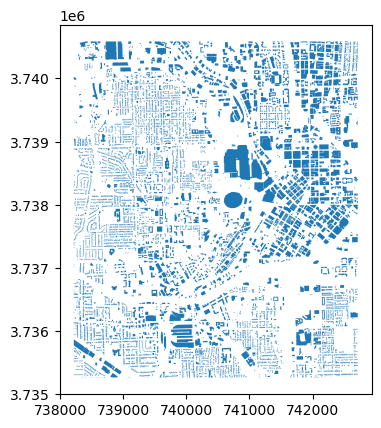

In [14]:
bd = bd[['id', 'bd_h', 'geometry']]
bd.plot();

In [17]:
bd.to_file("/storage/project/r-rbasu31-0/shared/Metro_Boston/Worldcup/Atlanta/Final ATL Files (Aligned)/Building/Building_clean.shp")